In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

# Load the cleaned feature dataset for model training.
df = pd.read_csv('data/extracted_video_data_clean.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Fill any missing values by carrying the previous frame's values forward.
for index, row in df.iterrows():
    if row.isnull().any():
        df.loc[index] = df.loc[index].fillna(df.loc[index - 1])

# Map fine-grained labels into simplified movement categories.
class_dict = {
    'closed_guard': 'ground',
    'open_guard': 'ground',
    'pin': 'ground',
    'submission': 'ground',
    'front_kick': 'kick',
    'head_kick': 'kick',
    'leg_kick': 'kick',
    'mid_kick': 'kick',
    'body_hook': 'punch',
    'jab': 'punch',
    'lead_hook': 'punch',
    'rear_hook': 'punch',
    'straight': 'punch',
    'double_leg': 'takedown',
    'single_leg': 'takedown',
    'sprawl': 'takedown',
    'not_engaged': 'not_engaged',
}
df['Label_Simplified'] = df['Label'].map(class_dict)

# Convert the frame identifier to an integer index for ordering and grouping.
df['Frame'] = df['Frame'].str[-4:].astype(int)

# Mark the start frame of each contiguous simplified label segment.
change = df['Label_Simplified'].ne(df['Label_Simplified'].shift())
df['Starting_Frame'] = df['Frame'].where(change).ffill().astype(int)

# Remove the original raw label as the simplified label is used for training.
df = df.drop(columns=['Label'])

# Balance the training set and create one-hot encoded labels for Keras.
X = df.drop(columns=['Label_Simplified'])
y = df['Label_Simplified']

rus = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = rus.fit_resample(X, y)

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X_balanced, y_balanced)

y_dummies = pd.get_dummies(y_balanced)
df1h = X_balanced.join(y_dummies)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

label_columns = ['ground', 'kick', 'not_engaged', 'punch', 'takedown']

# Convert the balanced dataset into feature and label arrays.
feature_columns = [
    col
    for col in df1h.columns
    if col not in ['Frame', 'Starting_Frame', 'Device', *label_columns]
]
X_flat = np.array(df1h[feature_columns], dtype=np.float32)
y_flat = np.array(df1h[label_columns], dtype=np.float32)

# Create a hold-out test split for evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_flat,
    test_size=0.1,
    random_state=42,
)

# Define a simple feedforward neural network as a baseline classifier.
mlp_model = Sequential([
    Dense(64, input_dim=X_flat.shape[1], activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(y_flat.shape[1], activation='softmax'),
])

optimizer = Adam(learning_rate=0.001)
mlp_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the MLP model and save the trained weights.
mlp_history = mlp_model.fit(
    X_train,
    y_train,
    epochs=169,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)

mlp_model.save('models/mlp_model.h5')
mlp_model = load_model('models/mlp_model.h5')


2026-05-30 14:21:54.122513: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-30 14:21:54.277995: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-30 14:21:54.466180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-30 14:21:54.674188: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-30 14:21:54.674944: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-30 14:21:54.943419: I tensorflow/core/platform/cpu_feature_guard.cc:

In [ ]:
# Evaluate the MLP model on the hold-out test set.
test_loss, test_accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy:.2f}')

# Generate predictions and convert one-hot outputs to class indices.
y_pred = mlp_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print and save the classification report for inspection.
report = classification_report(y_true, y_pred_classes, target_names=label_columns)
print(report)

with open('results/classification_report_mlp.txt', 'w') as f:
    f.write(report)


Test Accuracy: 0.45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

      ground       0.88      0.18      0.30        83
        kick       0.33      0.20      0.25        69
 not_engaged       0.75      0.33      0.46        72
       punch       0.42      0.88      0.57        68
    takedown       0.40      0.72      0.51        68

    accuracy                           0.45       360
   macro avg       0.55      0.46      0.42       360
weighted avg       0.57      0.45      0.41       360



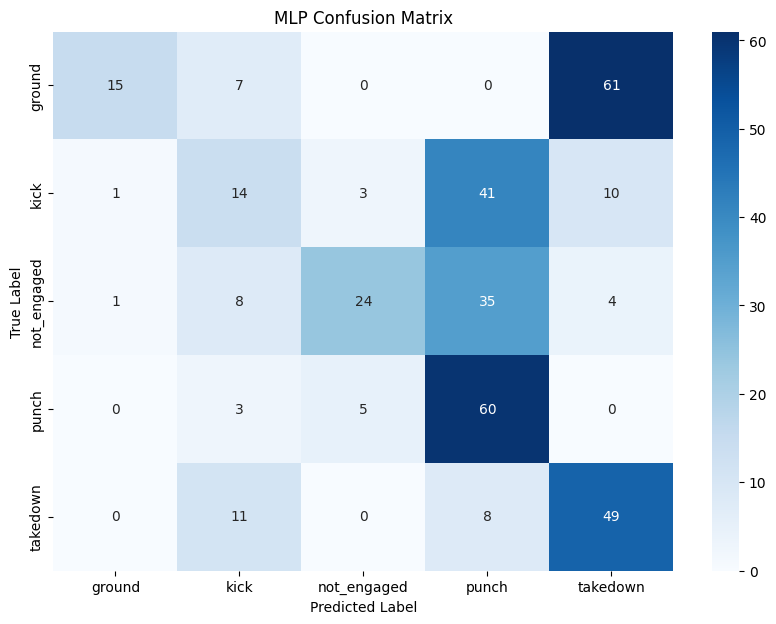

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute the confusion matrix so we can inspect where the MLP makes mistakes.
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_columns,
    yticklabels=label_columns,
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MLP Confusion Matrix')
plt.savefig('results/confusion_matrix_mlp.png')
plt.show()


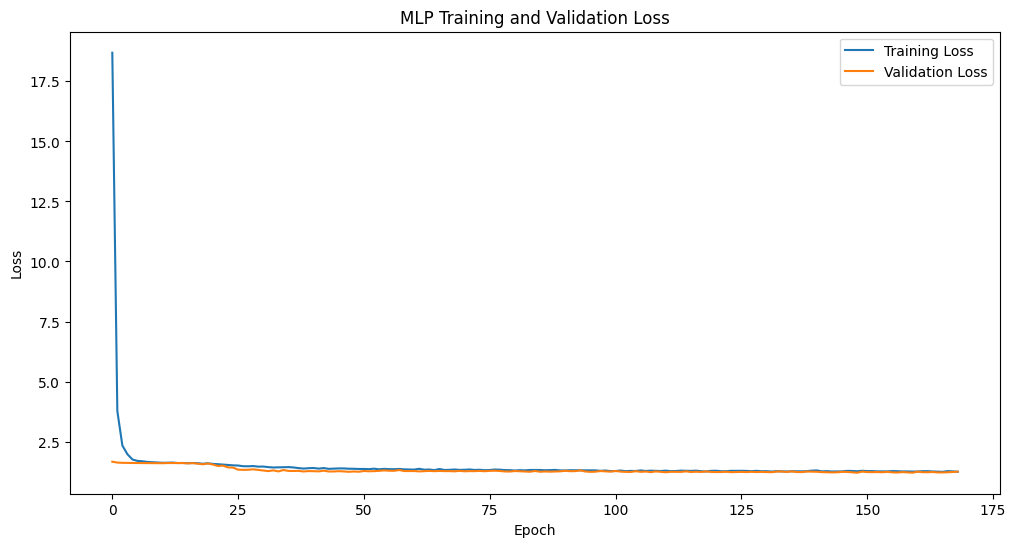

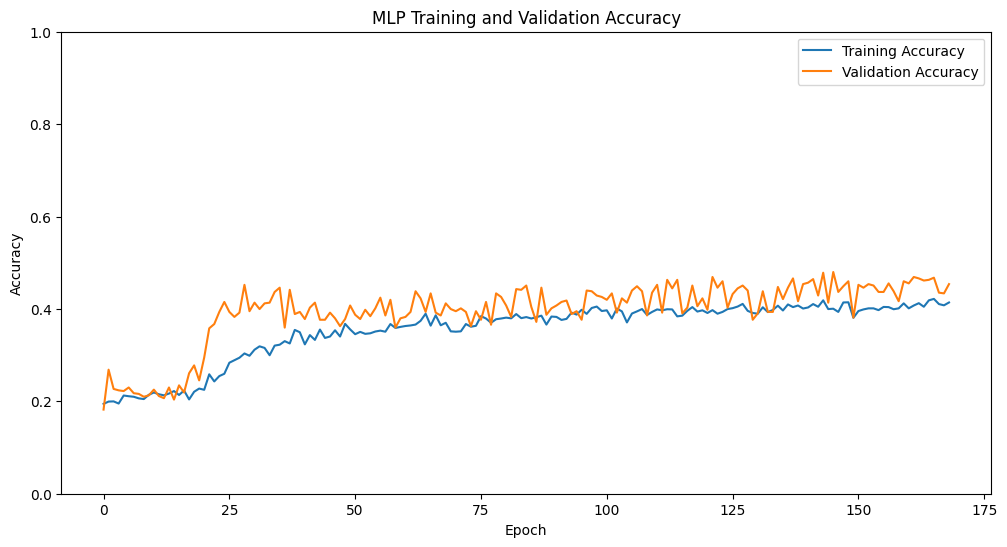

In [ ]:
history = mlp_history

# Plot training and validation loss over epochs to review model convergence.
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training and Validation Loss')
plt.legend()
plt.savefig('results/loss_plot_mlp.png')
plt.show()

# Plot training and validation accuracy over epochs.
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training and Validation Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.savefig('results/accuracy_plot_mlp.png')
plt.show()


In [ ]:
import numpy as np

# Define the window size for sequence modeling.
sequence_length = 16

X_seq, y_seq = [], []
label_columns = ['ground', 'kick', 'not_engaged', 'punch', 'takedown']
grouping_columns = ['Device', 'Starting_Frame']

# Select only feature columns that are not label metadata.
feature_columns = [col for col in df1h.columns if col not in label_columns]
feature_columns = [col for col in feature_columns if col not in grouping_columns]
feature_columns.remove('Frame')

# Sort frames to preserve temporal order before grouping.
df_sorted = df1h.sort_values(by=['Device', 'Starting_Frame', 'Frame']).reset_index(drop=True)

# Group frames by device and by each continuous movement segment.
grouped = df_sorted.groupby(grouping_columns)

for _, group in grouped:
    features = group[feature_columns].values
    labels = group[label_columns].values

    for start_idx in range(0, len(features) - sequence_length + 1):
        end_idx = start_idx + sequence_length
        X_seq.append(features[start_idx:end_idx])
        y_seq.append(labels[end_idx - 1])

    # If a movement segment is shorter than the sequence length, pad it with zeros.
    if len(features) < sequence_length:
        padded_features = np.pad(features, ((0, sequence_length - len(features)), (0, 0)), 'constant')
        X_seq.append(padded_features)
        y_seq.append(labels[-1])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f'X_seq shape: {X_seq.shape}')
print(f'y_seq shape: {y_seq.shape}')


X_seq shape: (3375, 16, 88)
y_seq shape: (3375, 5)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.models import load_model

# Split the sequences into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.1, random_state=42)

# Build an LSTM sequence model with masking for padded frames.
lstm_model = Sequential([
    Masking(mask_value=0., input_shape=(X_train.shape[1], X_train.shape[2])),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax'),
])

optimizer = Adam(learning_rate=0.001)
lstm_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=169,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)

lstm_model.save('models/lstm_model.h5')
lstm_model = load_model('models/lstm_model.h5')


/home/garymon/Downloads/CapstoneProjectUpdated/.venv/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Evaluate the saved LSTM model on the hold-out test sequences.
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy:.2f}')

# Convert probability outputs into class indices for reporting.
y_pred = lstm_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

report = classification_report(y_true, y_pred_classes, target_names=label_columns)
print(report)

with open('results/classification_report_lstm.txt', 'w') as f:
    f.write(report)


Test Accuracy: 0.99
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
              precision    recall  f1-score   support

      ground       1.00      0.98      0.99        64
        kick       0.98      0.98      0.98        56
 not_engaged       0.97      0.99      0.98        70
       punch       0.99      0.98      0.98        81
    takedown       0.99      1.00      0.99        67

    accuracy                           0.99       338
   macro avg       0.99      0.99      0.99       338
weighted avg       0.99      0.99      0.99       338



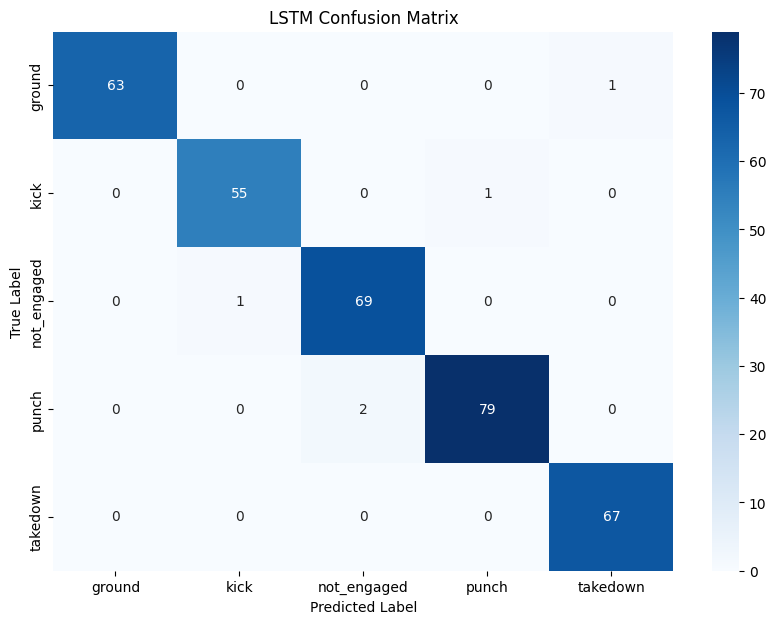

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_columns,
    yticklabels=label_columns,
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM Confusion Matrix')
plt.savefig('results/confusion_matrix_lstm.png')
plt.show()


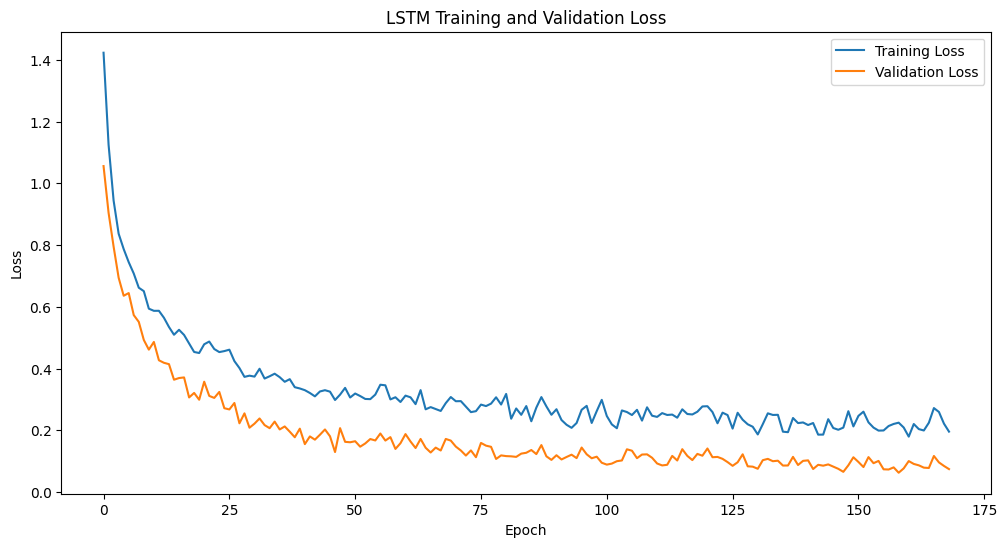

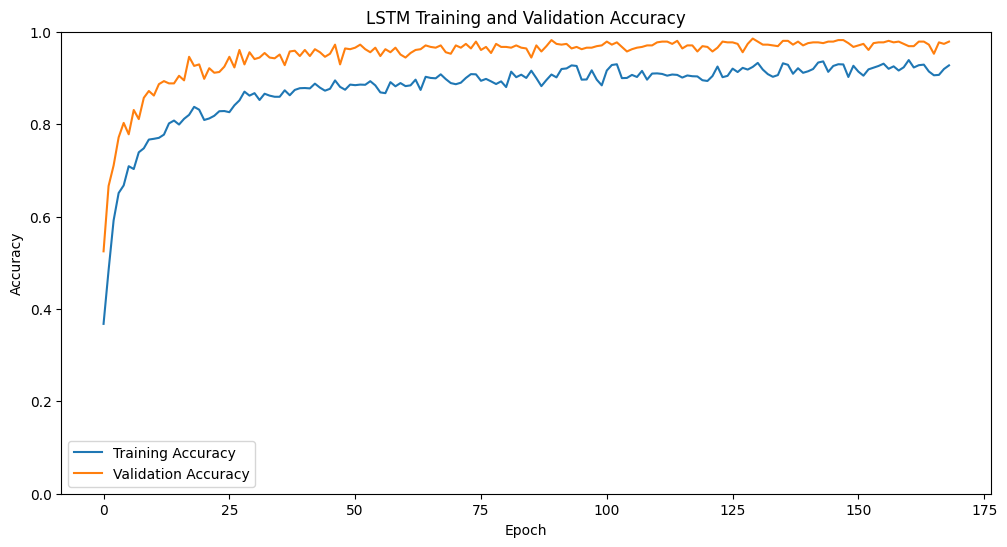

In [ ]:
history = lstm_history

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.savefig('results/loss_plot_lstm.png')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.savefig('results/accuracy_plot_lstm.png')
plt.show()
